<a href="https://colab.research.google.com/github/taruchit/Agentic-AI/blob/main/Translation_using_ModelPrompt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import openai

In [2]:
"""
from dotenv import load_dotenv, find_dotenv
_ = load_dotenv(find_dotenv()) # read local .env file
from google.colab import userdata
api_key = userdata.get('OPENAI_API_KEY')
os.environ['OPENAI_API_KEY'] = api_key
"""
from google.colab import userdata
api_key = userdata.get('OPENAI_API_KEY')
os.environ['OPENAI_API_KEY'] = api_key
from openai import OpenAI
import os
client = OpenAI(api_key=os.environ['OPENAI_API_KEY'])

In [3]:
# account for deprecation of LLM model
import datetime
# Get the current date
current_date = datetime.datetime.now().date()

# Define the date after which the model should be set to "gpt-3.5-turbo"
target_date = datetime.date(2024, 6, 12)

# Set the model variable based on the current date
if current_date > target_date:
    llm_model = "gpt-3.5-turbo"
else:
    llm_model = "gpt-3.5-turbo-0301"

In [4]:
#Helper function
def get_completion(prompt):
    response = client.chat.completions.create(
        model="gpt-4o-mini",   # or "gpt-4o"
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=0
    )
    return response.choices[0].message.content
"""
***old OpenAI API syntax (openai.ChatCompletion.create)***

def get_completion(prompt, model=llm_model):
    messages = [{"role": "user", "content": prompt}]
    response = openai.ChatCompletion.create(
        model=model,
        messages=messages,
        temperature=0,
    )
    return response.choices[0].message["content"]
"""

'\n***old OpenAI API syntax (openai.ChatCompletion.create)***\n\ndef get_completion(prompt, model=llm_model):\n    messages = [{"role": "user", "content": prompt}]\n    response = openai.ChatCompletion.create(\n        model=model,\n        messages=messages,\n        temperature=0, \n    )\n    return response.choices[0].message["content"]\n'

In [5]:
customer_email_French = """
J’ai eu une excellente expérience avec cette compagnie aérienne. \
Le personnel de bord était très professionnel, accueillant et toujours prêt à aider. \
L’embarquement s’est déroulé rapidement et le vol était confortable et ponctuel. \
Les repas servis à bord étaient délicieux et bien présentés. \
Je voyagerai certainement à nouveau avec cette compagnie et je la recommande vivement.
"""

<>:3: SyntaxWarning: invalid escape sequence '\ '
<>:3: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-2224693345.py:3: SyntaxWarning: invalid escape sequence '\ '
  Le personnel de bord était très professionnel, accueillant et toujours prêt à aider. \


In [6]:
style = """American English \
in a calm and respectful tone
"""

In [7]:
prompt = f"""Translate the text \
that is delimited by triple backticks
into a style that is {style}.
text: ```{customer_email_French}```
"""

print(prompt)

Translate the text that is delimited by triple backticks 
into a style that is American English in a calm and respectful tone
.
text: ```
J’ai eu une excellente expérience avec cette compagnie aérienne. Le personnel de bord était très professionnel, accueillant et toujours prêt à aider. \ 
L’embarquement s’est déroulé rapidement et le vol était confortable et ponctuel. \ 
Les repas servis à bord étaient délicieux et bien présentés. \ 
Je voyagerai certainement à nouveau avec cette compagnie et je la recommande vivement.
```



In [8]:
response = get_completion(prompt)
print(response)

I had an excellent experience with this airline. The cabin crew was very professional, welcoming, and always ready to assist. Boarding was quick, and the flight was comfortable and on time. The meals served on board were delicious and well-presented. I will definitely travel with this airline again, and I highly recommend it.


In [9]:
customer_email_Spanish="""
Tuve una experiencia excelente con esta aerolínea. \
El personal fue muy amable, profesional y atento en todo momento. \
El proceso de embarque fue rápido y organizado, y el vuelo salió y llegó a tiempo. \
Los asientos eran cómodos y el servicio a bordo fue de alta calidad. \
Sin duda volveré a volar con esta compañía y la recomiendo totalmente.
"""

In [10]:
prompt = f"""Translate the text \
that is delimited by triple backticks
into a style that is {style}.
text: ```{customer_email_Spanish}```
"""

print(prompt)

Translate the text that is delimited by triple backticks 
into a style that is American English in a calm and respectful tone
.
text: ```
Tuve una experiencia excelente con esta aerolínea. El personal fue muy amable, profesional y atento en todo momento. El proceso de embarque fue rápido y organizado, y el vuelo salió y llegó a tiempo. Los asientos eran cómodos y el servicio a bordo fue de alta calidad. Sin duda volveré a volar con esta compañía y la recomiendo totalmente.
```



In [11]:
response = get_completion(prompt)
print(response)

I had an excellent experience with this airline. The staff was very friendly, professional, and attentive at all times. The boarding process was quick and organized, and the flight departed and arrived on time. The seats were comfortable, and the in-flight service was of high quality. I will definitely fly with this company again and highly recommend it.


# **LangChain**

In [12]:
#!pip install --upgrade langchain langchain-openai openai

In [13]:
from langchain_openai import ChatOpenAI
"""
LangChain changed its package structure (v0.1+ and especially v0.2+).

ChatOpenAI is no longer imported from:
from langchain.chat_models import ChatOpenAI
"""

'\nLangChain changed its package structure (v0.1+ and especially v0.2+).\n\nChatOpenAI is no longer imported from:\nfrom langchain.chat_models import ChatOpenAI\n'

In [14]:
chat = ChatOpenAI(temperature=0.0, model=llm_model)
chat

ChatOpenAI(profile={'max_input_tokens': 16385, 'max_output_tokens': 4096, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': False, 'structured_output': False, 'image_url_inputs': False, 'pdf_inputs': False, 'pdf_tool_message': False, 'image_tool_message': False, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x7c7271b05eb0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7c725325b290>, root_client=<openai.OpenAI object at 0x7c72536e85f0>, root_async_client=<openai.AsyncOpenAI object at 0x7c7271b04f50>, temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

In [15]:
template_string = """Translate the text \
that is delimited by triple backticks \
into a style that is {style}. \
text: ```{text}```
"""

In [17]:
from langchain_core.prompts import ChatPromptTemplate
"""
In modern LangChain, many core components were moved out of langchain into:
langchain_core

#from langchain.prompts import ChatPromptTemplate
"""
prompt_template = ChatPromptTemplate.from_template(template_string)

In [18]:
prompt_template.messages[0].prompt

PromptTemplate(input_variables=['style', 'text'], input_types={}, partial_variables={}, template='Translate the text that is delimited by triple backticks into a style that is {style}. text: ```{text}```\n')

In [19]:
prompt_template.messages[0].prompt.input_variables

['style', 'text']

In [20]:
customer_style = """British English \
in a calm and respectful tone
"""

In [21]:
customer_email_German="""
Ich hatte eine sehr positive Erfahrung mit dieser Fluggesellschaft. \
Das Kabinenpersonal war freundlich, professionell und jederzeit hilfsbereit. \
Das Boarding verlief reibungslos und der Flug war pünktlich. \
Die Sitze waren bequem und der Service an Bord war ausgezeichnet. \
Ich würde jederzeit wieder mit dieser Airline fliegen und kann sie sehr empfehlen.
"""

In [22]:
customer_messages=prompt_template.format_messages(
    style=customer_style,
    text=customer_email_German
)

In [23]:
print(type(customer_messages))

<class 'list'>


In [24]:
print(type(customer_messages[0]))

<class 'langchain_core.messages.human.HumanMessage'>


In [25]:
print(customer_messages[0])

content='Translate the text that is delimited by triple backticks into a style that is British English in a calm and respectful tone\n. text: ```\nIch hatte eine sehr positive Erfahrung mit dieser Fluggesellschaft. Das Kabinenpersonal war freundlich, professionell und jederzeit hilfsbereit. Das Boarding verlief reibungslos und der Flug war pünktlich. Die Sitze waren bequem und der Service an Bord war ausgezeichnet. Ich würde jederzeit wieder mit dieser Airline fliegen und kann sie sehr empfehlen.\n```\n' additional_kwargs={} response_metadata={}


In [27]:
# Calling the LLM to translate to the style of customer message
customer_response = chat.invoke(customer_messages)

"""
# Old method : LLM objects are called like functions
customer_response = chat(customer_messages)

In modern LangChain (0.2+), LLM objects are not called like functions anymore.
Correct method: - chat.invoke(...)
"""
print(customer_response.content)

I had a very positive experience with this airline. The cabin crew were friendly, professional, and always helpful. The boarding process was smooth and the flight was on time. The seats were comfortable and the onboard service was excellent. I would not hesitate to fly with this airline again and highly recommend it.


In [28]:
ack_reply="""We are glad to know that you had great experience.\
We will look forward to serve you again.
"""

In [29]:
ack_style_German="""\
a polite tone that speaks in German \
"""

In [30]:
ack_message=prompt_template.format_messages(
    style=ack_style_German,
    text=ack_reply
)

In [32]:
print(ack_message[0].content)

Translate the text that is delimited by triple backticks into a style that is a polite tone that speaks in German . text: ```We are glad to know that you had great experience.We will look forward to serve you again.
```



In [33]:
ack_response=chat.invoke(ack_message)
print(ack_response.content)

Wir freuen uns zu hören, dass Sie eine großartige Erfahrung hatten. Wir freuen uns darauf, Sie wieder zu bedienen.


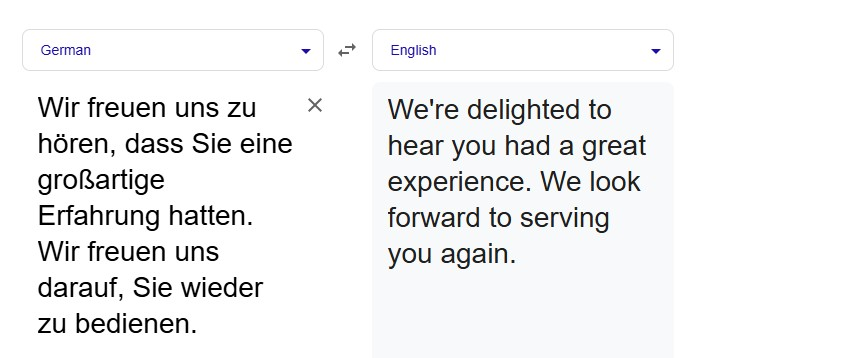